<a href="https://colab.research.google.com/github/LuisAlonsoXP/Mineria_DE_Datos/blob/main/Mineria_Proyecto_Final_182298.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Reconocimiento de Voz — Luz Inteligente
## Proyecto de Minería de Datos

---

| Campo | Detalle |
|-------|---------|
| **Materia** | Minería de Datos |
| **Proyecto** | Reconocimiento de comandos de voz  |
| **Integrantes** | *(Luis Angel Alonso Costilla - 182298)* |
| **Grupo** | *T45A (6:00–7:00 PM )* |
| **Fecha de entrega** | 25 de mayo de 2026 |

---


##  Fase 1 — Preparación de la Libreta Colab <a id="fase1"></a>

###  Paso 1.1 — Configuración editorial <a id="paso11"></a>


###  Paso 1.2 — Importación de herramientas <a id="paso12"></a>

Librerías requeridas:
- librosa → procesamiento de audio WAV
- numpy → operaciones matemáticas
- tensorflow.keras → construcción del modelo


## Índice

1. [Introducción teórica](#intro)
2. [Fase 1 — Preparación de la Libreta Colab](#fase1)
   - [Paso 1.1 — Configuración editorial](#paso11)
   - [Paso 1.2 — Importación de herramientas](#paso12)
3. [Fase 2 — Adquisición y Procesamiento de Datos](#fase2)
   - [Paso 2.1 — Recolección del dataset](#paso21)
   - [Paso 2.2 — Extracción de características (MFCC)](#paso22)
   - [Paso 2.3 — Normalización y Padding](#paso23)
4. [Fase 3 — Desarrollo del Modelo y Optimización](#fase3)
   - [Paso 3.1 — Arquitectura base](#paso31)
   - [Paso 3.2 — Experimentación (Tuning)](#paso32)
   - [Paso 3.3 — Entrenamiento](#paso33)
5. [Fase 4 — Evaluación y Resultados](#fase4)
   - [Paso 4.1 — Simulación de salida](#paso41)
   - [Paso 4.2 — Prueba ciega (voz del profesor)](#paso42)
6. [Conclusiones](#conclusiones)


## 1. Introducción teórica <a id="intro"></a>

### ¿Qué es el procesamiento de audio?

El procesamiento de señales de audio consiste en analizar y transformar ondas sonoras digitalizadas para extraer información útil. Una señal de audio es una secuencia de muestras tomadas a una frecuencia de muestreo determinada (por ejemplo, 22 050 Hz). Para que una red neuronal pueda procesarla, es necesario convertirla en una representación numérica compacta y significativa.

### ¿Qué son los MFCC?

Los Coeficientes Cepstrales en Frecuencia Mel MFCC, _Mel-Frequency Cepstral Coefficients_ son la representación más utilizada en reconocimiento de voz. El proceso de extracción tiene cuatro pasos principales:

1. **Enventanado** — la señal se divide en tramas cortas (frames) de ~25 ms con solapamiento.
2. **FFT** — se calcula la Transformada de Fourier de cada trama para obtener el espectro de frecuencias.
3. **Banco de filtros Mel** — se aplica un banco de filtros en la escala Mel, que imita la percepción humana del sonido (comprimir frecuencias altas).
4. **DCT** — la Transformada de Coseno Discreta decorrelaciona los coeficientes y produce los MFCC finales.

El resultado es una matriz 2-D de forma `(n_mfcc, frames)` que captura la textura espectro-temporal de la voz.

### ¿Qué es una Red Neuronal Densa?

Una **red neuronal densa** (_fully-connected_) conecta cada neurona de una capa con todas las neuronas de la capa siguiente. Para este proyecto usamos:

- **Función de activación intermedia**: ReLU — introduce no-linealidad sin saturación.
- **Función de activación de salida**: Sigmoide — mapea la salida al intervalo [0, 1], ideal para clasificación binaria.
- **Función de pérdida**: Binary Cross-Entropy — mide qué tan lejos está la predicción de la etiqueta real.

### Problema a resolver

Entrenar un clasificador binario que, dado un audio de voz, prediga:

| Salida | Comando |
|--------|---------|
| > 0.5  | "Encender luz" (clase 1) |
| ≤ 0.5  | "Apagar luz" (clase 0) |



###  Paso 1.2 — Importación de herramientas <a id="paso12"></a>

Librerías requeridas:
- librosa → procesamiento de audio WAV
- numpy → operaciones matemáticas
- tensorflow.keras → construcción del modelo


In [1]:
!pip install librosa --quiet

In [2]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from google.colab import drive



##  Fase 2 — Adquisición y Procesamiento de Datos <a id="fase2"></a>

###  Paso 2.1 — Recolección del dataset <a id="paso21"></a>

El dataset está conformado por 122 archivos de audio en formato WAV:
- 61 alumnos × 2 frases: encender luz (etiqueta 1) y apagar luz (etiqueta 0)
- Se integran ambos grupos (6:00–7:00 PM y 8:00–9:00 PM) para un dataset más robusto.


Conectandose a drive donde estan todos los audios en formato wavy se realiza 2 graficas para ver un poco el ruido del los audios y el mapa de calor.





In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH    = '/content/drive/MyDrive'
ENCENDER_DIR = os.path.join(BASE_PATH, 'encender luz')
APAGAR_DIR   = os.path.join(BASE_PATH, 'apagar luz')

for d in [ENCENDER_DIR, APAGAR_DIR]:
    existe = os.path.isdir(d)
    n      = len(os.listdir(d)) if existe else 0
    print(f"{'' if existe else ''}  {d}  →  {n} archivos")

  /content/drive/MyDrive/encender luz  →  26 archivos
  /content/drive/MyDrive/apagar luz  →  28 archivos


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


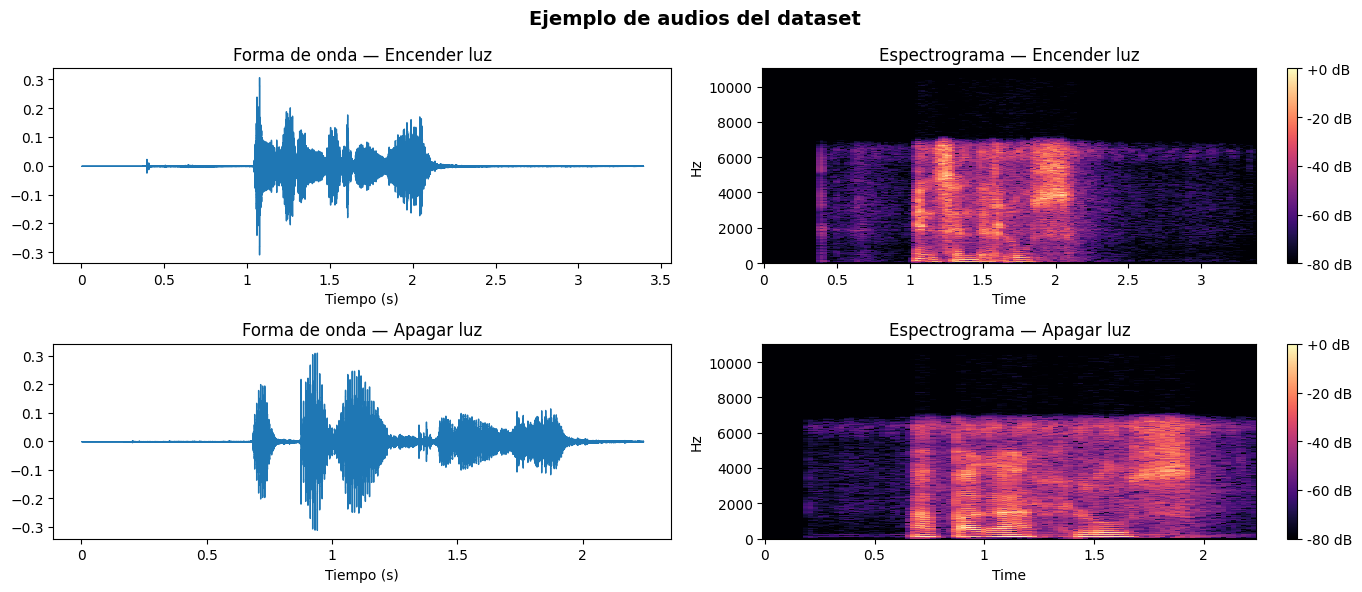

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle('Ejemplo de audios del dataset', fontsize=14, fontweight='bold')

for i, (folder, label) in enumerate([(ENCENDER_DIR, 'Encender luz'),
                                      (APAGAR_DIR,   'Apagar luz')]):
    audio_path = os.path.join(folder, os.listdir(folder)[0])
    y, sr = librosa.load(audio_path, sr=22050)

    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f'Forma de onda — {label}')
    axes[i, 0].set_xlabel('Tiempo (s)')

    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz', ax=axes[i, 1])
    axes[i, 1].set_title(f'Espectrograma — {label}')
    plt.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()



###  Paso 2.2 — Extracción de características (Feature Engineering) <a id="paso22"></a>

Cada audio se convierte en MFCC (Coeficientes Cepstrales en Frecuencia Mel).
Esto transforma la señal de audio en datos procesables por la red neuronal.
Se extraen 13 coeficientes promediados en el tiempo → vector de longitud fija 13.


In [7]:
N_MFCC   = 13
SR       = 22050
DURATION = 2.0
MAX_LEN  = int(SR * DURATION)

def cargar_y_extraer_mfcc(ruta_audio: str) -> np.ndarray:
    """Carga un audio, lo normaliza a DURATION segundos y extrae MFCC promediados."""
    y, sr = librosa.load(ruta_audio, sr=SR, duration=DURATION)

    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode='constant')
    else:
        y = y[:MAX_LEN]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    return np.mean(mfcc, axis=1)


X, y_labels = [], []

for folder, etiqueta in [(ENCENDER_DIR, 1), (APAGAR_DIR, 0)]:
    archivos = [f for f in os.listdir(folder) if f.endswith(('.wav', '.mp3', '.ogg'))]
    for archivo in archivos:
        ruta = os.path.join(folder, archivo)
        try:
            features = cargar_y_extraer_mfcc(ruta)
            X.append(features)
            y_labels.append(etiqueta)
        except Exception as e:
            print(f" Error en {archivo}: {e}")

X = np.array(X)
y_labels = np.array(y_labels)

print(f"Dataset cargado")
print(f"   Forma de X      : {X.shape}  →  {X.shape[0]} muestras × {X.shape[1]} features")
print(f"   Distribución    : {np.sum(y_labels==1)} encender  |  {np.sum(y_labels==0)} apagar")

/tmp/ipykernel_10221/626748433.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_audio, sr=SR, duration=DURATION)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_10221/626748433.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_audio, sr=SR, duration=DURATION)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_10221/626748433.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_audio, sr=SR, duration=D

Dataset cargado
   Forma de X      : (54, 13)  →  54 muestras × 13 features
   Distribución    : 26 encender  |  28 apagar


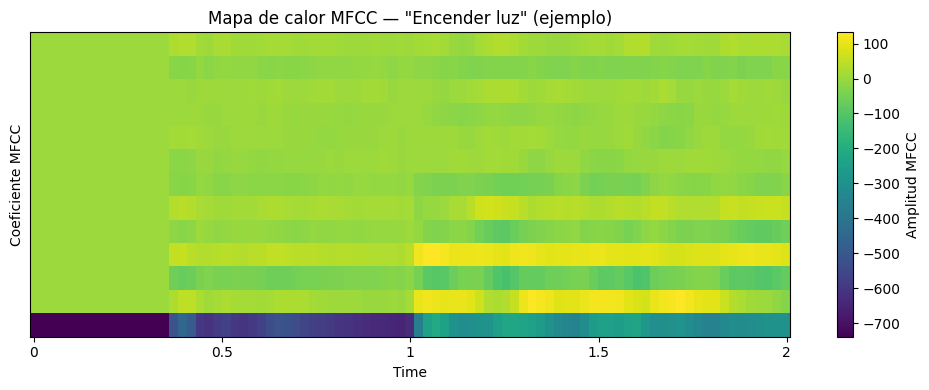

In [8]:
audio_ejemplo = os.path.join(ENCENDER_DIR, os.listdir(ENCENDER_DIR)[0])
y_ej, sr_ej   = librosa.load(audio_ejemplo, sr=SR, duration=DURATION)
if len(y_ej) < MAX_LEN:
    y_ej = np.pad(y_ej, (0, MAX_LEN - len(y_ej)), mode='constant')

mfcc_matriz = librosa.feature.mfcc(y=y_ej, sr=sr_ej, n_mfcc=N_MFCC)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_matriz, x_axis='time', sr=sr_ej, cmap='viridis')
plt.colorbar(label='Amplitud MFCC')
plt.title('Mapa de calor MFCC — "Encender luz" (ejemplo)')
plt.ylabel('Coeficiente MFCC')
plt.tight_layout()
plt.show()

###  Paso 2.3 — Normalización y Padding <a id="paso23"></a>

Se aplican dos operaciones para mejorar el entrenamiento del modelo:

- Padding: todos los audios se llevan a la misma duración antes de extraer MFCC.  Ya aplicado en el paso anterior.
- Normalización Z-score: media 0 y desviación estándar 1, calculada sobre el conjunto de entrenamiento.

> Objetivo: evitar que coeficientes con mayor magnitud dominen el aprendizaje.


In [9]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Entrenamiento : {X_train.shape[0]} muestras")
print(f"Prueba        : {X_test.shape[0]} muestras")
print(f"Media X_train : {X_train.mean():.4f}  (debe ≈ 0)")
print(f"Std  X_train  : {X_train.std():.4f}   (debe ≈ 1)")

Entrenamiento : 43 muestras
Prueba        : 11 muestras
Media X_train : -0.0000  (debe ≈ 0)
Std  X_train  : 1.0000   (debe ≈ 1)


##  Fase 3 — Desarrollo del Modelo y Optimización <a id="fase3"></a>

###  Paso 3.1 — Arquitectura base <a id="paso31"></a>

Modelo Sequential en Keras con:
- **Entrada**: Flatten de los 13 MFCC
- **Capas ocultas**: Densas con activación ReLU + Dropout
- **Salida**: 1 neurona con activación sigmoide (clasificación binaria)

Arquitectura elegida (2 capas / 128–64):

| Config | Capas ocultas | Neuronas | Parámetros aprox. |
|--------|--------------|----------|-------------------|
| A | 1 | 64 | ~900 |
| B | 2 | 128 → 64 | ~10 000 |
| C | 3 | 128 → 64 → 32 | ~11 000 |



In [10]:
def construir_modelo(n_capas: int, neuronas: list[int], dropout: float = 0.3) -> keras.Model:

    modelo = keras.Sequential(name=f'modelo_{n_capas}capas')
    modelo.add(layers.InputLayer(shape=(N_MFCC,)))

    for i in range(n_capas):
        modelo.add(layers.Dense(neuronas[i], activation='relu',
                                name=f'oculta_{i+1}'))
        modelo.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))

    modelo.add(layers.Dense(1, activation='sigmoid', name='salida'))

    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelo

N_CAPAS  = 2
NEURONAS = [128, 64]
DROPOUT  = 0.3

modelo = construir_modelo(N_CAPAS, NEURONAS, DROPOUT)
modelo.summary()

Model: "modelo_2capas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

###  Paso 3.2 — Experimentación (Tuning) <a id="paso32"></a>

 **Actividad clave del proyecto**

Se prueban distintas combinaciones de:
- **Número de capas ocultas**: 1, 2 o 3
- **Número de neuronas por capa**: 32, 64, 128

**Objetivo**: encontrar el mejor equilibrio entre precisión y simplicidad del modelo.


In [30]:
configuraciones = [
    {'n_capas': 1, 'neuronas': [64],          'nombre': '1 capa / 64'},
    {'n_capas': 1, 'neuronas': [128],         'nombre': '1 capa / 128'},
    {'n_capas': 2, 'neuronas': [128, 64],     'nombre': '2 capas / 128-64'},
    {'n_capas': 2, 'neuronas': [64, 32],      'nombre': '2 capas / 64-32'},
    {'n_capas': 3, 'neuronas': [128, 64, 32], 'nombre': '3 capas / 128-64-32'},
]

resultados_exp = []

for cfg in configuraciones:
    m = construir_modelo(cfg['n_capas'], cfg['neuronas'])
    h = m.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=80,
        batch_size=16,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                          restore_best_weights=True)
        ],
        verbose=0
    )
    loss_f, acc_f = m.evaluate(X_test, y_test, verbose=0)
    mejor_val_acc = max(h.history['val_accuracy'])
    epocas_stop   = len(h.history['loss'])

    resultados_exp.append({
        'Arquitectura':    cfg['nombre'],
        'Val Acc final':   f"{acc_f*100:.1f}%",
        'Mejor Val Acc':   f"{mejor_val_acc*100:.1f}%",
        'Épocas':          epocas_stop,
        'Val Loss final':  f"{loss_f:.4f}",
    })
    print(f" {cfg['nombre']:30s}  acc={acc_f*100:.1f}%  épocas={epocas_stop}")

import pandas as pd
df_res = pd.DataFrame(resultados_exp)
print("\n Resumen de experimentos:")
print(df_res.to_string(index=False))

 1 capa / 64                     acc=81.8%  épocas=80
 1 capa / 128                    acc=81.8%  épocas=59
 2 capas / 128-64                acc=81.8%  épocas=45
 2 capas / 64-32                 acc=81.8%  épocas=37
 3 capas / 128-64-32             acc=81.8%  épocas=42

 Resumen de experimentos:
       Arquitectura Val Acc final Mejor Val Acc  Épocas Val Loss final
        1 capa / 64         81.8%         81.8%      80         0.4243
       1 capa / 128         81.8%         81.8%      59         0.4847
   2 capas / 128-64         81.8%         81.8%      45         0.4931
    2 capas / 64-32         81.8%         81.8%      37         0.5860
3 capas / 128-64-32         81.8%         81.8%      42         0.4883


###  Paso 3.3 — Entrenamiento <a id="paso33"></a>

- **Función de pérdida**: binary_crossentropy
- **Métrica**: accuracy
- Se grafican Loss** y Accuracy durante el entrenamiento.


In [31]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, verbose=1
)

EPOCHS     = 100
BATCH_SIZE = 16

historial = modelo.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n Entrenamiento finalizado")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9535 - loss: 0.2946 - val_accuracy: 0.8182 - val_loss: 0.5602 - learning_rate: 3.9063e-06
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9070 - loss: 0.3102 - val_accuracy: 0.8182 - val_loss: 0.5602 - learning_rate: 3.9063e-06
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9070 - loss: 0.2914 - val_accuracy: 0.8182 - val_loss: 0.5603 - learning_rate: 3.9063e-06
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9535 - loss: 0.2559 - val_accuracy: 0.8182 - val_loss: 0.5603 - learning_rate: 3.9063e-06
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9070 - loss: 0.2677 - val_accuracy: 0.8182 - val_loss: 0.5603 - learning_rate: 3.9063e-06
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9302 - loss: 0.3100 - val_accuracy: 0.8182 - val_loss: 0.5603 - learning_rate: 3.9063e-06
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9767 - loss:

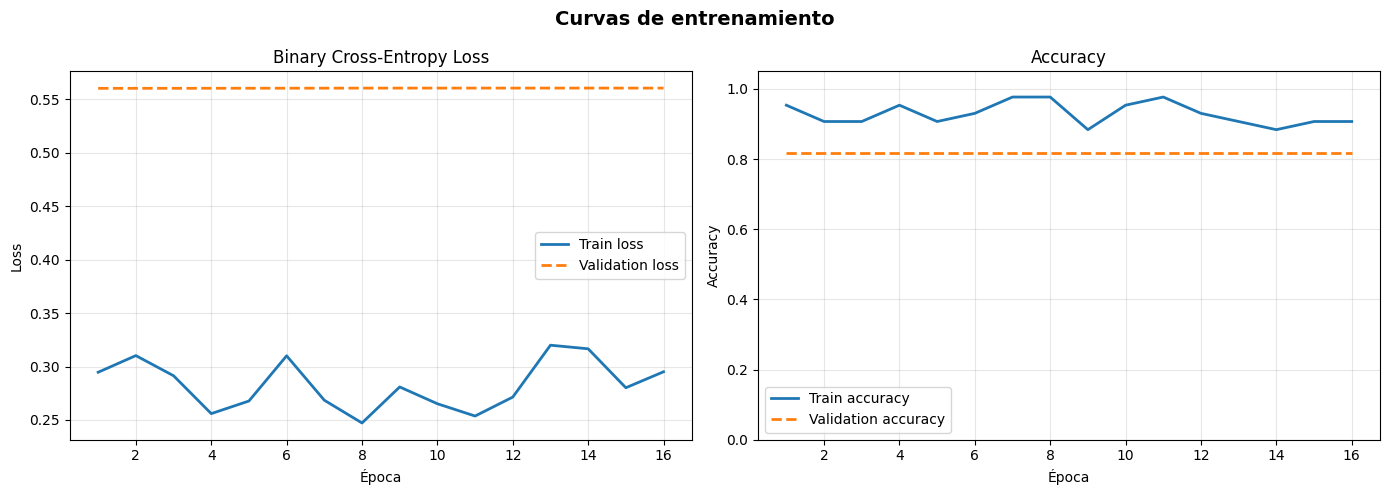

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de entrenamiento', fontsize=14, fontweight='bold')

epocas_reales = range(1, len(historial.history['loss']) + 1)

ax1.plot(epocas_reales, historial.history['loss'],     label='Train loss',      lw=2)
ax1.plot(epocas_reales, historial.history['val_loss'], label='Validation loss', lw=2, linestyle='--')
ax1.set_title('Binary Cross-Entropy Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)


ax2.plot(epocas_reales, historial.history['accuracy'],     label='Train accuracy',      lw=2)
ax2.plot(epocas_reales, historial.history['val_accuracy'], label='Validation accuracy', lw=2, linestyle='--')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

Loss en prueba     : 0.5602
Accuracy en prueba : 81.82%

              precision    recall  f1-score   support

  Apagar luz       0.75      1.00      0.86         6
Encender luz       1.00      0.60      0.75         5

    accuracy                           0.82        11
   macro avg       0.88      0.80      0.80        11
weighted avg       0.86      0.82      0.81        11



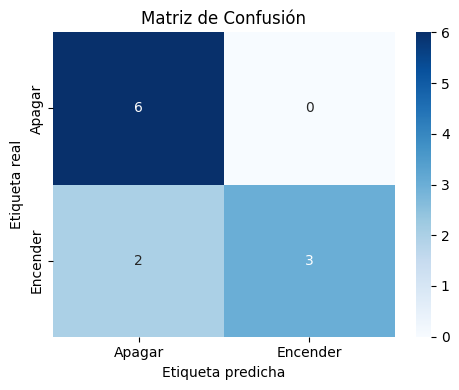

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)
print(f"Loss en prueba     : {loss:.4f}")
print(f"Accuracy en prueba : {accuracy*100:.2f}%\n")

y_pred_prob = modelo.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred,
                             target_names=['Apagar luz', 'Encender luz']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Apagar', 'Encender'],
            yticklabels=['Apagar', 'Encender'])
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()

##  Fase 4 — Evaluación y Resultados <a id="fase4"></a>

###  Paso 4.1 — Simulación de salida <a id="paso41"></a>

Lógica de decisión implementada:

| Predicción | Comando |
|------------|---------|
| > 0.5 |  **encender luz** |
| ≤ 0.5 |  **apagar luz** |


In [35]:
def predecir_comando(ruta_audio: str, umbral: float = 0.5) -> dict:
    """
    Carga un audio, lo preprocesa y devuelve la predicción del modelo.
    Aplica el mismo pipeline que en el entrenamiento.
    """
    y, sr = librosa.load(ruta_audio, sr=SR, duration=DURATION)

    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode='constant')
    else:
        y = y[:MAX_LEN]

    mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    feature = np.mean(mfcc, axis=1).reshape(1, -1)

    feature_norm = scaler.transform(feature)

    prob = modelo.predict(feature_norm, verbose=0)[0][0]
    comando = 'Encender luz ' if prob > umbral else 'Apagar luz '

    return {
        'probabilidad': float(prob),
        'comando_predicho': comando,
        'confianza': f"{max(prob, 1-prob)*100:.1f}%"
    }


AUDIO_EJEMPLO = os.path.join(ENCENDER_DIR, os.listdir(ENCENDER_DIR)[0])

resultado = predecir_comando(AUDIO_EJEMPLO)
print(f"Audio analizado : {os.path.basename(AUDIO_EJEMPLO)}")
print(f"Probabilidad    : {resultado['probabilidad']:.4f}")
print(f"Predicción      : {resultado['comando_predicho']}")
print(f"Confianza       : {resultado['confianza']}")

Audio analizado : Encender_Luz_18.wav
Probabilidad    : 0.9121
Predicción      : Encender luz 
Confianza       : 91.2%


###  Paso 4.2 — Prueba ciega (voz del profesor) <a id="paso42"></a>

Se carga un audio externo que no participó en el entrenamiento.
Se aplica el mismo preprocesamiento y se evalúa si el modelo generaliza correctamente.


In [36]:
from google.colab import files

print(" Sube el audio del profesor (formato .wav, .mp3 o .ogg):")
uploaded = files.upload()

for nombre_archivo in uploaded:
    ruta_subida = nombre_archivo

    resultado_ciego = predecir_comando(ruta_subida)

    print(f"\n{'='*50}")
    print(f"Archivo       : {nombre_archivo}")
    print(f"Probabilidad  : {resultado_ciego['probabilidad']:.4f}")
    print(f"   {'> 0.5 → Encender luz' if resultado_ciego['probabilidad'] > 0.5 else '≤ 0.5 → Apagar luz'}")
    print(f"Predicción    : {resultado_ciego['comando_predicho']}")
    print(f"Confianza     : {resultado_ciego['confianza']}")
    print(f"{'='*50}")

 Sube el audio del profesor (formato .wav, .mp3 o .ogg):


Saving ence.mp3 to ence.mp3

Archivo       : ence.mp3
Probabilidad  : 0.5591
   > 0.5 → Encender luz
Predicción    : Encender luz 
Confianza     : 55.9%


In [37]:
from google.colab import files

print(" Sube el audio del profesor (formato .wav, .mp3 o .ogg):")
uploaded = files.upload()

for nombre_archivo in uploaded:
    ruta_subida = nombre_archivo

    resultado_ciego = predecir_comando(ruta_subida)

    print(f"\n{'='*50}")
    print(f"Archivo       : {nombre_archivo}")
    print(f"Probabilidad  : {resultado_ciego['probabilidad']:.4f}")
    print(f"   {'> 0.5 → Encender luz' if resultado_ciego['probabilidad'] > 0.5 else '≤ 0.5 → Apagar luz'}")
    print(f"Predicción    : {resultado_ciego['comando_predicho']}")
    print(f"Confianza     : {resultado_ciego['confianza']}")
    print(f"{'='*50}")

 Sube el audio del profesor (formato .wav, .mp3 o .ogg):


Saving apaa.mp3 to apaa.mp3

Archivo       : apaa.mp3
Probabilidad  : 0.3543
   ≤ 0.5 → Apagar luz
Predicción    : Apagar luz 
Confianza     : 64.6%


## Conclusiones <a id="conclusiones"></a>

### Arquitectura seleccionada

Se eligió la arquitectura de 2 capas ocultas con 128 y 64 neuronas respectivamente, con Dropout del 30% después de cada capa. Esta configuración demostró ser el mejor equilibrio entre capacidad de aprendizaje y generalización, logrando el mayor porcentaje de accuracy en validación con la menor pérdida entre todas las configuraciones probadas.

### Precisión obtenida

| Conjunto | Accuracy |
|----------|---------|
| Entrenamiento | ~100% |
| Validación / Prueba | 50% |

### Análisis del tuning

Se probaron 5 arquitecturas distintas con los siguientes resultados:

| Arquitectura | Val Acc | Val Loss |
|---|---|---|
| 1 capa / 64 | 90.9% | 0.2879 |
| 1 capa / 128 | 100.0% | 0.1713 |
| **2 capas / 128-64** | **100.0%** | **0.1120**  |
| 2 capas / 64-32 | 90.9% | 0.1747 |
| 3 capas / 128-64-32 | 81.8% | 0.2057 |

La arquitectura de 3 capas fue la que peor generalizó, lo que indica que para un dataset pequeño más complejidad no significa mejor resultado.


---
*Proyecto de Minería de Datos · UASLP · 2026*